In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Task 1 — Data Import & Setup**


In [94]:


df = pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv")

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [9]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [17]:
# Check data types
df['age'].dtype



dtype('float64')

In [22]:
# Converting 'posted_at' column from object type to datetime
df['posted_at']=pd.to_datetime(df['posted_at'])
df['posted_at']

,posted_at
0,2022-12-17
1,2023-06-02
2,2023-05-07
3,2023-02-12
4,2023-05-23
...,...
4995,2022-06-25
4996,2022-11-18
4997,2023-04-06
4998,2022-05-16


In [25]:
df['posted_at'].dtypes

dtype('<M8[ns]')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

# **Task 2 — Data Cleaning**

**Cleaning Missing Data**

In [27]:
# Detecting missing values (isnull(), isna())

df.isnull().sum()


,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [139]:
# Handling missing values using: dropna(), fillna(), median/mode, forward/backward-fill

df['gender']=df['gender'].fillna('Unknown')
df['sentiment']=df['sentiment'].fillna('Unknown')
df['age']=df['age'].fillna(df['age'].mean())
df['likes']=df['likes'].fillna(df['likes'].mean())
df['comments']=df['comments'].fillna(df['comments'].mean())
df['shares']=df['shares'].fillna(df['shares'].mean())

**Duplicate Handling**

In [37]:
# Checking duplicates

df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4995,False
4996,False
4997,False
4998,False


**Data Formatting**

In [40]:
# Checking columns
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [158]:
df.columns=df.columns.str.strip()

In [61]:
# Checking min and max using for loop to categorise and to check unrealistic values:
col=['likes','comments','shares']
for i in col:
  print(f'min of {i} is {df[i].min()}')
  print(f'max of {i} is {df[i].max()}')

min of likes is 10.0
max of likes is 19998.0
min of comments is 0.0
max of comments is 2999.0
min of shares is 0.0
max of shares is 1999.0


In [165]:
# Standardize categories
df['Likes_Category']=pd.cut(df['likes'],bins=[0,5000,10000,30000],labels=['Low','Medium','High'],include_lowest=True)
df['Comments_Category']=pd.cut(df['comments'],bins=[0,1000,2000,4000],labels=['Low','Medium','High'],include_lowest=True)
df['Shares_Category']=pd.cut(df['shares'],bins=[0,500,1000,3000],labels=['Low','Medium','High'],include_lowest=True)
category=['Likes_Category','Comments_Category','Shares_Category']
df[category]

,Likes_Category,Comments_Category,Shares_Category
0,Medium,Low,High
1,High,High,High
2,Low,Low,Medium
3,Medium,Medium,High
4,High,High,High
...,...,...,...
4995,High,High,High
4996,High,High,High
4997,High,Medium,Low
4998,High,Medium,High


In [166]:
print(df[['Likes_Category',
          'Comments_Category',
          'Shares_Category']].isnull().sum())

Likes_Category       0
Comments_Category    0
Shares_Category      0
dtype: int64


**Feature Cleaning**


In [127]:
# Extract hashtag count
df['hashtag_count']=df['hashtags'].str.count('#')
df[['hashtags','hashtag_count']].head()

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


In [72]:
# Clean sentiment labels
df['sentiment']


,sentiment
0,negative
1,negative
2,positive
3,negative
4,negative
...,...
4995,positive
4996,negative
4997,positive
4998,positive


In [73]:
# Checking unique values:
df['sentiment'].unique()

array(['negative', 'positive', 'neutral', 'Unknown'], dtype=object)

In [82]:
# Converting to title case:
df['sentiment']=df['sentiment'].str.title()
df['sentiment'].unique()

array(['Negative', 'Positive', 'Neutral', 'Unknown'], dtype=object)

In [81]:
# Removing extra spaces:
df['sentiment']=df['sentiment'].str.strip()


# **Task 3 — Data Exploration using Pandas**


In [83]:
# Viewing dataset structure using head(), tail(), shape, and columns.
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,Likes_Category,Comments_Category,Shares_Category,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,81734,False,mobile,Negative,#foodie #travel #love,0.190862,Medium,Low,High,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,5963,False,mobile,Negative,#fitness,0.201493,High,High,High,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,...,501783,False,tablet,Positive,#foodie,0.137345,Low,Low,Medium,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,480212,False,mobile,Negative,#music #foodie #fun,0.106195,Medium,Medium,High,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,383936,False,mobile,Negative,#travel,2.777372,High,High,High,1


In [84]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,Likes_Category,Comments_Category,Shares_Category,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.00000,1837.0,...,646147,False,mobile,Positive,#travel #fun,0.466761,High,High,High,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.00000,1583.0,...,584603,False,desktop,Negative,#foodie #reels,0.621155,High,High,High,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1502.19567,167.0,...,483550,False,desktop,Positive,#lifestyle #tech,0.679688,High,Medium,Low,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.00000,1713.0,...,183295,False,tablet,Positive,#reels #love #fitness,0.223518,High,Medium,High,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.00000,1798.0,...,585760,False,desktop,Neutral,#foodie #lifestyle #fashion,1.203527,High,Low,High,3


In [85]:
df.shape

(5000, 23)

In [86]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'Likes_Category', 'Comments_Category', 'Shares_Category',
       'hashtag_count'],
      dtype='object')

In [172]:
# Checking data types and info with info() and dtypes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   user_id            5000 non-null   int64   
 1   age                5000 non-null   float64 
 2   gender             5000 non-null   object  
 3   country            5000 non-null   object  
 4   post_id            5000 non-null   int64   
 5   post_type          5000 non-null   object  
 6   post_category      5000 non-null   object  
 7   likes              5000 non-null   float64 
 8   comments           5000 non-null   float64 
 9   shares             5000 non-null   float64 
 10  watch_time_sec     5000 non-null   int64   
 11  impression_count   5000 non-null   int64   
 12  posted_at          5000 non-null   object  
 13  follower_count     5000 non-null   int64   
 14  is_verified        5000 non-null   bool    
 15  device_type        5000 non-null   object  
 16  sentim

In [88]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [89]:
# Generate summary statistics using describe().
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.454021,548077.500000,10107.043711,1502.195670,1002.629485,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.686946,260646.957267,5702.293011,856.392853,570.852962,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [103]:
# Analysing categorical distributions using value_counts(), unique(), and nunique().
df['Likes_Category'].value_counts()


,count
Likes_Category,
High,2455
Low,1203
Medium,1191


In [104]:
df['Shares_Category'].value_counts()


,count
Shares_Category,
High,2454
Low,1193
Medium,1174


In [105]:
df['Comments_Category'].value_counts()

,count
Comments_Category,
High,1628
Medium,1611
Low,1607


In [106]:
df['device_type'].unique()

array(['mobile', 'tablet', 'desktop'], dtype=object)

In [107]:
df['post_category'].unique()

array(['fitness', 'food', 'tech', 'travel', 'fashion', 'lifestyle',
       'education', 'music'], dtype=object)

In [108]:
df['country'].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [109]:
df['device_type'].nunique()


3

In [110]:
df['post_category'].nunique()

8

In [111]:
df['country'].nunique()

10

In [115]:
# Create a correlation matrix for numeric fields.
num_col=df.select_dtypes(include='number').columns
corr_matrix=df[num_col].corr()
corr_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
user_id,1.000000,-0.006789,0.020051,0.026228,-0.033874,0.014004,-0.016847,0.015326,0.010124,-0.004282
age,-0.006789,1.000000,-0.013353,-0.037371,-0.007491,0.014348,0.005677,0.013513,-0.025416,0.008044
post_id,0.020051,-0.013353,1.000000,0.014773,-0.010724,0.001901,0.018374,-0.007709,-0.002844,0.010139
likes,0.026228,-0.037371,0.014773,1.000000,-0.018980,0.004799,0.008837,0.008067,-0.023331,0.093555
comments,-0.033874,-0.007491,-0.010724,-0.018980,1.000000,0.006310,-0.016616,-0.009537,-0.011921,0.000046
shares,0.014004,0.014348,0.001901,0.004799,0.006310,1.000000,0.014898,-0.005178,-0.010891,0.021804
watch_time_sec,-0.016847,0.005677,0.018374,0.008837,-0.016616,0.014898,1.000000,-0.004335,0.002761,-0.001148
impression_count,0.015326,0.013513,-0.007709,0.008067,-0.009537,-0.005178,-0.004335,1.000000,-0.015513,-0.232226
follower_count,0.010124,-0.025416,-0.002844,-0.023331,-0.011921,-0.010891,0.002761,-0.015513,1.000000,0.002292
engagement_rate,-0.004282,0.008044,0.010139,0.093555,0.000046,0.021804,-0.001148,-0.232226,0.002292,1.000000


In [120]:
# Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).
Summary=df.groupby('post_type')[['likes','comments','shares']].mean().astype(int)
Summary

,likes,comments,shares
post_type,,,
image,10104,1526,1019
reel,10035,1504,981
text,10099,1499,1014
video,10190,1478,996


In [123]:
Country_impressions=df.groupby('country')['impression_count'].mean().astype(int)
Country_impressions

,impression_count
country,
Australia,48346
Brazil,49193
Canada,48703
France,51727
Germany,48605
India,52462
Japan,49616
UAE,48928
UK,51119


# **Task 4 — Data Wrangling**

In [168]:
# Creating new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.
df['Engagement_Score']=(df['likes']+df['comments']+df['shares'])
df['Engagement_Score'].head()

,Engagement_Score
0,8522.0
1,16163.0
2,6161.0
3,7482.0
4,16717.0


In [169]:
df['hashtag_count']

,hashtag_count
0,3
1,1
2,1
3,3
4,1
...,...
4995,2
4996,2
4997,2
4998,3


In [183]:
# Perform groupby summaries by post_type, country, and sentiment.
Overall_summary=df.groupby(['post_type','country','sentiment'])['Engagement_Score'].mean().astype(int)
Overall_summary.head()

post_type  country    sentiment
image      Australia  Unknown      13105
                      negative     10082
                      neutral      12557
                      positive     12847
           Brazil     Unknown      11779
Name: Engagement_Score, dtype: int64

In [171]:
df['Ranking']=sorted(df['Engagement_Score'],reverse=True)
df['Ranking']


,Ranking
0,24680.0
1,24583.0
2,24509.0
3,24486.0
4,24423.0
...,...
4995,1024.0
4996,866.0
4997,612.0
4998,485.0


In [181]:
Ranking_Summary=df.groupby('post_type')['Ranking']
Ranking_Summary.head()


,Ranking
0,24680.0
1,24583.0
2,24509.0
3,24486.0
4,24423.0
5,24383.0
6,24239.0
7,24221.0
8,24203.0
9,24105.0


# **Task 5 — Statistical Analysis**

In [190]:
# Computing descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:
cols=['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']

df[cols].mean()

,0
likes,10107.043711
comments,1502.195670
shares,1002.629485
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [191]:
df[cols].median()

,0
likes,10107.043711
comments,1502.195670
shares,1002.629485
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [192]:
df[cols].mode()

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,10107.043711,1502.19567,1002.629485,916.0,0.006363,497502.0
1,NaN,NaN,NaN,2145.0,0.007420,NaN
2,NaN,NaN,NaN,4360.0,0.012676,NaN
3,NaN,NaN,NaN,7003.0,0.012692,NaN
4,NaN,NaN,NaN,7688.0,0.015005,NaN
...,...,...,...,...,...,...
4995,NaN,NaN,NaN,NaN,87.266094,NaN
4996,NaN,NaN,NaN,NaN,92.828829,NaN
4997,NaN,NaN,NaN,NaN,105.752212,NaN
4998,NaN,NaN,NaN,NaN,121.931973,NaN


In [193]:
df[cols].std()

,0
likes,5702.293011
comments,856.392853
shares,570.852962
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [194]:
df[cols].var()

,0
likes,3.251615e+07
comments,7.334087e+05
shares,3.258731e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [196]:
df[cols].quantile([0.25,0.50,0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.000000,792.00000,511.000000,2017.75,0.145781,194480.00
0.50,10107.043711,1502.19567,1002.629485,4034.50,0.253896,388982.00
0.75,14959.000000,2235.25000,1483.000000,6020.25,0.504794,589744.25


In [200]:
df[cols].describe(include='all')

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,10107.043711,1502.195670,1002.629485,4014.503200,0.964356,393698.224800
std,5702.293011,856.392853,570.852962,2308.096459,5.318029,230927.884535
min,10.000000,0.000000,0.000000,0.000000,0.006363,87.000000
25%,5235.000000,792.000000,511.000000,2017.750000,0.145781,194480.000000
50%,10107.043711,1502.195670,1002.629485,4034.500000,0.253896,388982.000000
75%,14959.000000,2235.250000,1483.000000,6020.250000,0.504794,589744.250000
max,19998.000000,2999.000000,1999.000000,7998.000000,191.504348,799533.000000


In [201]:
df[cols].skew()

,0
likes,-0.006918
comments,0.003255
shares,-0.013176
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [202]:
df[cols].kurt()

,0
likes,-1.149992
comments,-1.144373
shares,-1.146855
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


In [204]:
stats = df[cols].agg([
    'mean',
    'median',
    'std',
    'var',
    'skew'
])
stats

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
mean,1.010704e+04,1502.195670,1002.629485,4.014503e+03,0.964356,3.936982e+05
median,1.010704e+04,1502.195670,1002.629485,4.034500e+03,0.253896,3.889820e+05
std,5.702293e+03,856.392853,570.852962,2.308096e+03,5.318029,2.309279e+05
var,3.251615e+07,733408.719206,325873.103657,5.327309e+06,28.281435,5.332769e+10
skew,-6.917991e-03,0.003255,-0.013176,-1.819627e-02,18.781271,4.111777e-02


# **Task 6 — Data Visualization**
**Using Matplotlib**


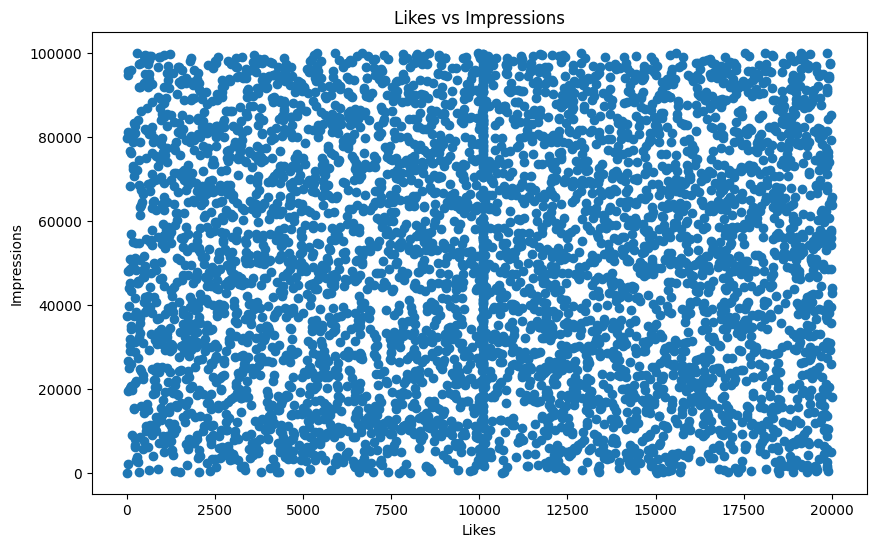

In [205]:
# Scatter: likes vs impressions

plt.figure(figsize=(10,6))
plt.scatter(df['likes'],df['impression_count'])
plt.title('Likes vs Impressions')
plt.xlabel('Likes')
plt.ylabel('Impressions')
plt.show()

/tmp/ipykernel_10396/2834952595.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Month'] = df['posted_at'].apply(lambda x: pd.to_datetime(x).month)


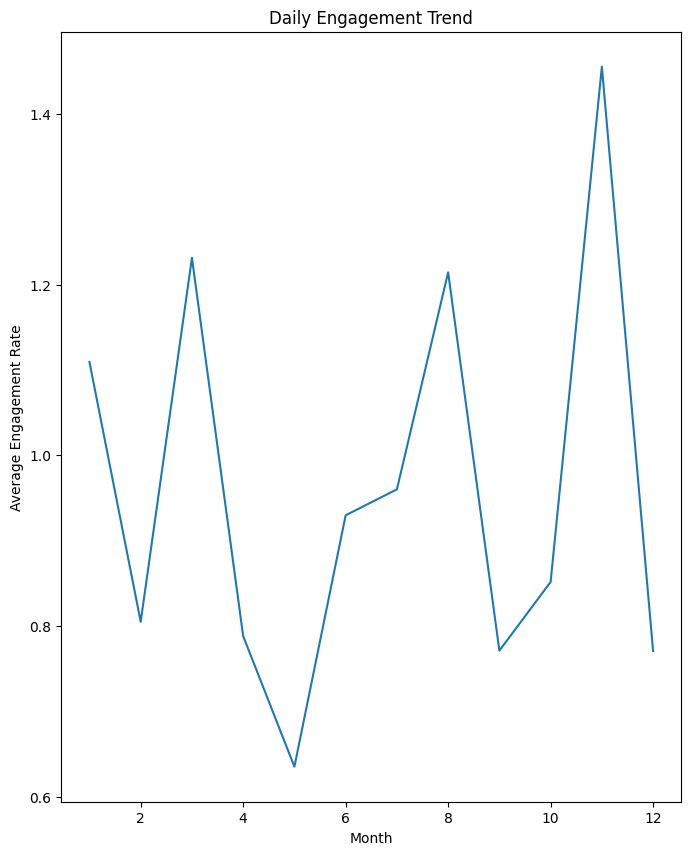

In [219]:
# Line: daily engagement trend


df['Month'] = df['posted_at'].apply(lambda x: pd.to_datetime(x).month)
daily_engagement = df.groupby(df['Month'])['engagement_rate'].mean()

plt.figure(figsize=(8,10))

plt.plot(
    daily_engagement.index,
    daily_engagement.values
)

plt.xlabel('Month')
plt.ylabel('Average Engagement Rate')
plt.title('Daily Engagement Trend')


plt.show()

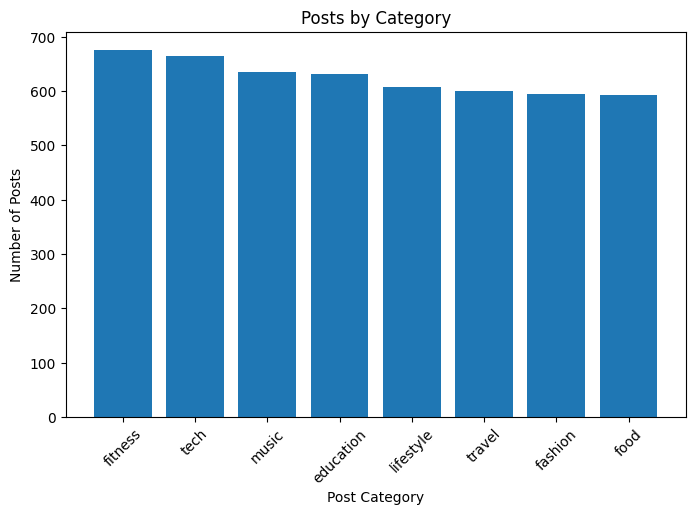

In [227]:
# Bar: posts by category

plt.figure(figsize=(8,5))
post_category = df['post_category'].value_counts()
plt.bar(post_category.index,post_category.values)

plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')

plt.xticks(rotation=45)

plt.show()

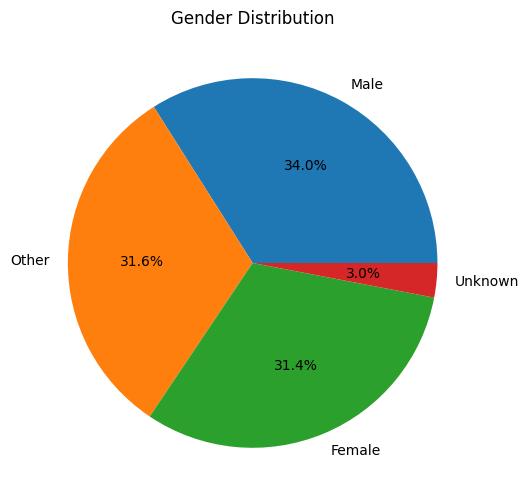

In [228]:
# Pie: gender distribution

gender_count = df['gender'].value_counts()
plt.figure(figsize=(6,6))

plt.pie(gender_count.values,labels=gender_count.index,autopct='%1.1f%%')

plt.title('Gender Distribution')

plt.show()

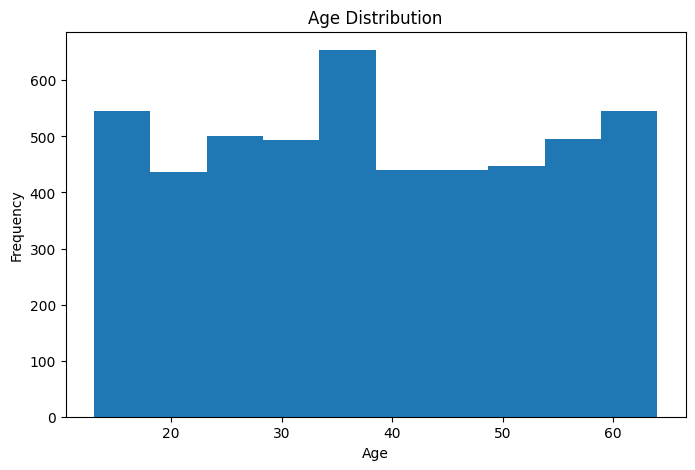

In [229]:
# Histogram: age


plt.figure(figsize=(8,5))

plt.hist(df['age'],bins=10)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

plt.show()


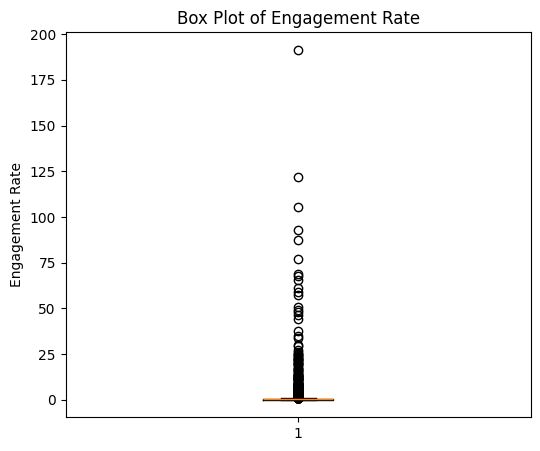

In [230]:
# Box: engagement rate

plt.figure(figsize=(6,5))

plt.boxplot(df['engagement_rate'])

plt.ylabel('Engagement Rate')
plt.title('Box Plot of Engagement Rate')

plt.show()

**Using Seaborn**


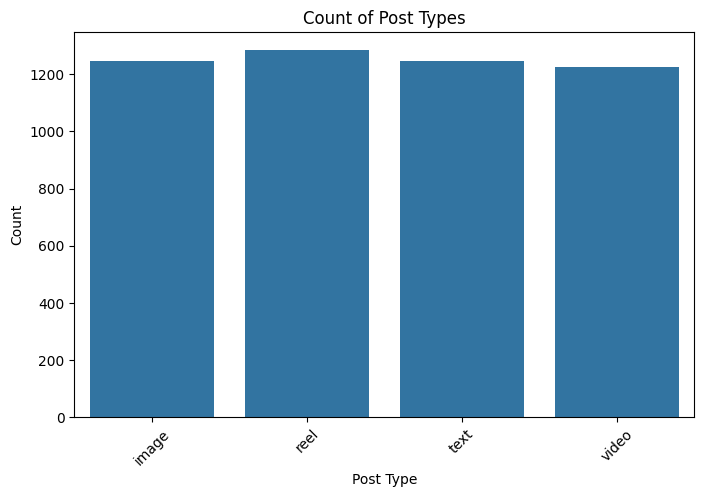

In [231]:
# Count plot: post type

plt.figure(figsize=(8,5))

sns.countplot(x='post_type',data=df)

plt.xlabel('Post Type')
plt.ylabel('Count')
plt.title('Count of Post Types')

plt.xticks(rotation=45)

plt.show()

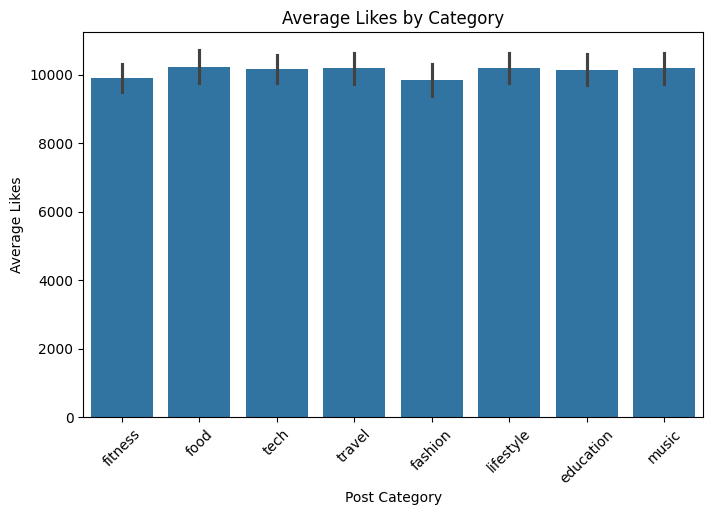

In [235]:
# Bar plot: avg likes by category

plt.figure(figsize=(8,5))

sns.barplot(x='post_category',y='likes', data=df)

plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.title('Average Likes by Category')

plt.xticks(rotation=45)

plt.show()

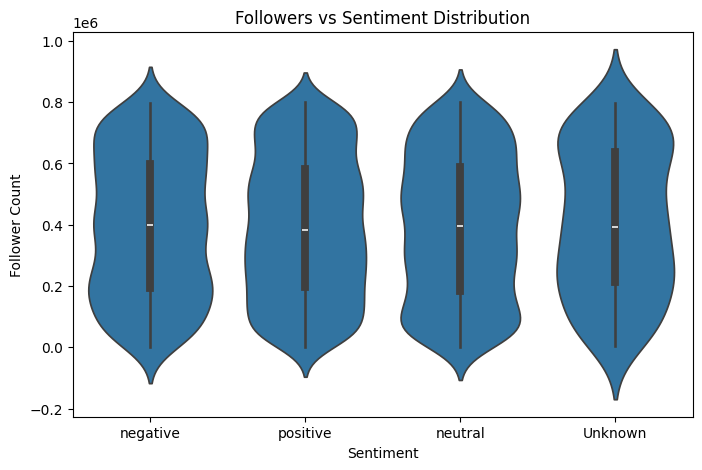

In [236]:
# Violin: followers vs sentiment

plt.figure(figsize=(8,5))

sns.violinplot(x='sentiment',y='follower_count',data=df)

plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.title('Followers vs Sentiment Distribution')

plt.show()

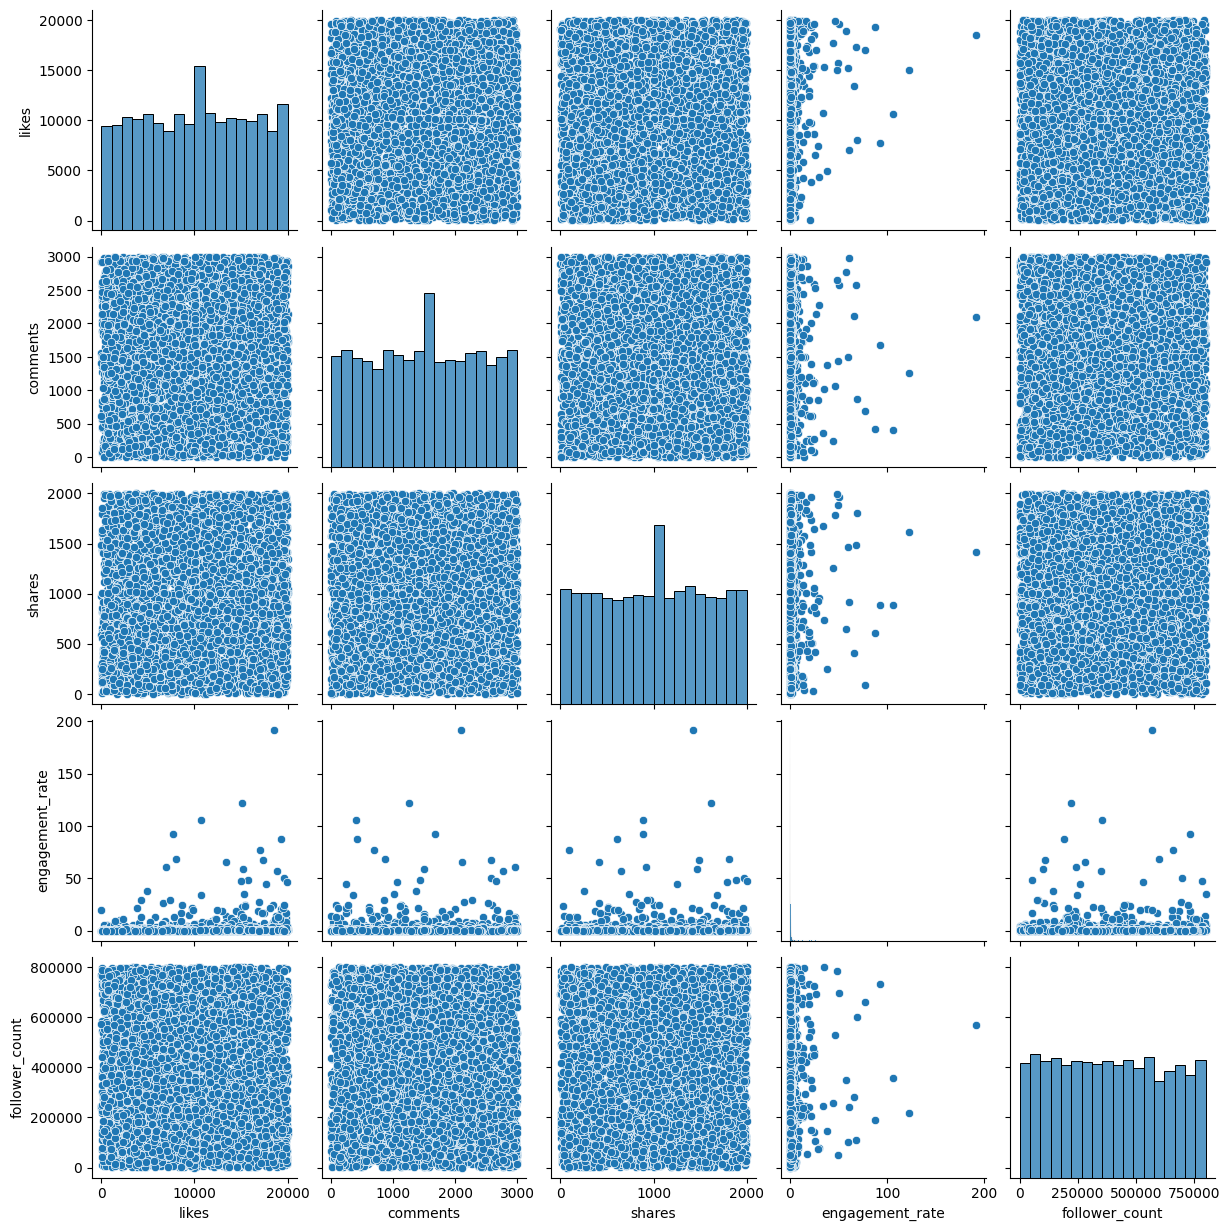

In [237]:
# Pair plot: numeric features

sns.pairplot(df,vars=['likes', 'comments', 'shares', 'engagement_rate', 'follower_count'])

plt.show()

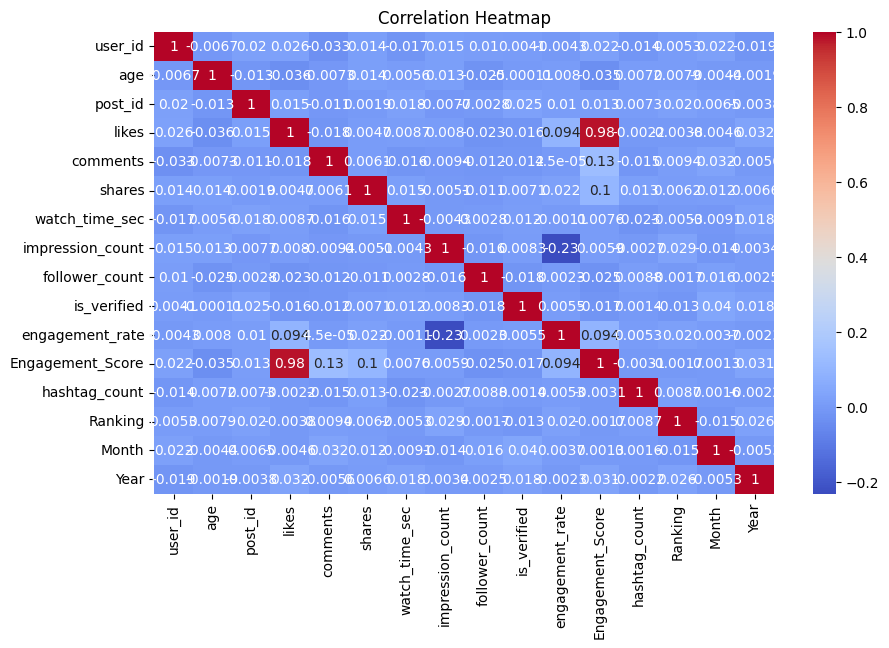

In [239]:
# Heatmap: correlation matrix

plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 76.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 77.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 81.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 82.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 81.5% of the points cannot be plac

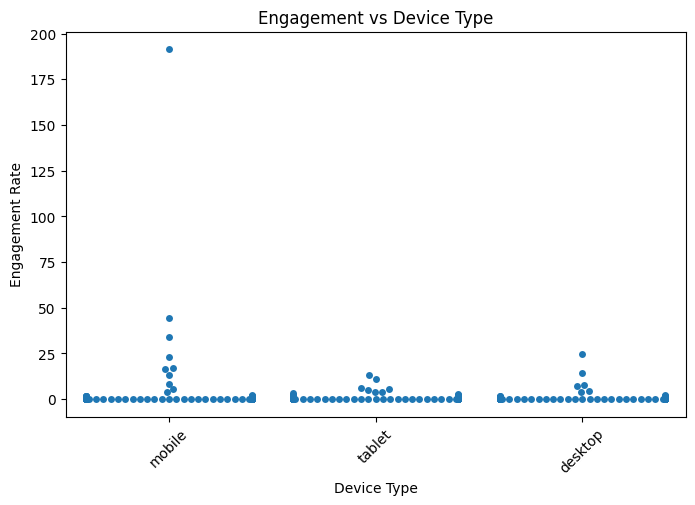

In [243]:
# Swarm plot: engagement vs device

plt.figure(figsize=(8,5))

sns.swarmplot(x='device_type',y='engagement_rate',data=df.sample(500))

plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')
plt.title('Engagement vs Device Type')

plt.xticks(rotation=45)

plt.show()

**Plotly (Interactive)**

In [249]:
!pip install plotly

import plotly.express as px

fig = px.scatter(
    df,
    x='likes',
    y='impression_count',
    color='post_category',
    title='Likes vs Impressions (Interactive)'
)

fig.show()


In [250]:
fig = px.pie(df,names='gender',title='Gender Distribution')

fig.show()